In [1]:
import pickle

import scanpy as sc

import scvi
from benchmark_utils import (
    add_cell_types_grouped,
    preprocess_scrna,
    load_bulk_facs,
    load_bulk_facs_tpm,
    create_dirichlet_pseudobulk_dataset,
    create_anndata_pseudobulk,
    create_latent_signature,
)

from benchmark_utils.latent_signature_utils import create_latent_signature

from constants import (
    N_GENES,
    TRAINING_CELL_TYPE_GROUP,
)

/home/owkin/deepdeconv-fork/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/owkin/deepdeconv-fork/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
mixup_model_path = "project/model_final_debug"

#Here we load the filtered genes that were used to fit the model (they were already intersected with the bulk data)
with open(f"{mixup_model_path}/filtered_genes_final_debug.pkl", "rb") as f:
    mixup_filtered_genes = pickle.load(f)

In [3]:
scvi_model_path = "project/scvi_model/"

with open(f"{scvi_model_path}/final_filtered_genes_scvi.pkl", "rb") as f:
    scvi_filtered_genes = pickle.load(f)

In [4]:
set(mixup_filtered_genes) == set(scvi_filtered_genes)

True

### Loading CTI Data

In [7]:
cti_adata = sc.read("/home/owkin/project/cti/cti_adata.h5ad")
preprocess_scrna(cti_adata, keep_genes=N_GENES, batch_key="donor_id")
cell_type = f"cell_types_grouped_{TRAINING_CELL_TYPE_GROUP}"

cti_adata, train_test_index = add_cell_types_grouped(cti_adata, TRAINING_CELL_TYPE_GROUP)

cti_adata.obs["cell_types_grouped"] = cti_adata.obs[cell_type] #THIS SHOULD NOT BE DONE  

cti_adata_train = cti_adata[train_test_index["Train index"]]
cti_adata_test = cti_adata[train_test_index["Test index"]]

cti_adata_train = cti_adata_train[:, mixup_filtered_genes]

In [8]:
cti_adata_train

View of AnnData object with n_obs × n_vars = 144607 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cell_type_ontology_term_id_colors', 'default_embedding', 'schema_version', 'sex_ontology_term_i

Here we sample just 200 cells (40 cells from each cell type) for displaying purposes.

In [9]:
import numpy as np

# Sample a small representative dataset with equal numbers of cells from each cell type group
n_cells_per_type = 40 # Number of cells to sample from each type
cell_types = cti_adata_train.obs[cell_type].unique()

sampled_indices = []
for ct in cell_types:
    ct_indices = cti_adata_train.obs[cti_adata_train.obs[cell_type] == ct].index
    if len(ct_indices) >= n_cells_per_type:
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=False)
    else:
        # If not enough cells, sample with replacement
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=True)
    sampled_indices.extend(sampled)

small_sc_dataset = cti_adata_train[sampled_indices].copy()


In [10]:
small_sc_dataset

AnnData object with n_obs × n_vars = 200 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cell_type_ontology_term_id_colors', 'default_embedding', 'schema_version', 'sex_ontology_term_id_colors', 

### Loading Bulk FACS Data

In [11]:
bulk_data = load_bulk_facs()
bulk_data["dataset"] = bulk_data["dataset"].loc[mixup_filtered_genes]

In [12]:
obs_names = bulk_data["dataset"].columns
bulk_data["dataset"] = create_anndata_pseudobulk(
                adata_obs=cti_adata_train.obs,
                adata_var_names=mixup_filtered_genes,
                x=bulk_data["dataset"].T.values,
            )

In [13]:
bulk_data["dataset"]

AnnData object with n_obs × n_vars = 206 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    layers: 'counts'

### Loading Bulk Facs TPM

In [14]:
bulk_data_tpm = load_bulk_facs_tpm()
bulk_data_tpm["dataset"] = bulk_data_tpm["dataset"].loc[mixup_filtered_genes]
obs_names = bulk_data_tpm["dataset"].columns
bulk_data_tpm["dataset"] = create_anndata_pseudobulk(
                adata_obs=cti_adata_train.obs,
                adata_var_names=mixup_filtered_genes,
                x=bulk_data_tpm["dataset"].T.values,
                )
bulk_data_tpm["dataset"]

AnnData object with n_obs × n_vars = 206 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    layers: 'counts'

### Generating Pseudobulks Data with "mean" aggregation

In [15]:
pseudobulks_data_mean = create_dirichlet_pseudobulk_dataset(cti_adata_train, cell_type_group=cell_type, n_cells=1024, n_sample = 200, aggregation_method="mean")
pseudobulks_data_mean["adata_pseudobulk_test_counts"]

AnnData object with n_obs × n_vars = 200 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    layers: 'counts'

In [16]:
### Generating Pseudobulks Data with "sum" aggregation
pseudobulks_data_sum = create_dirichlet_pseudobulk_dataset(cti_adata_train, cell_type_group=cell_type, n_cells=1024, n_sample = 200, aggregation_method="sum")
pseudobulks_data_sum["adata_pseudobulk_test_counts"]

AnnData object with n_obs × n_vars = 200 × 1993
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_FACS_1st_level_granularity', 'cell_types_grouped'
    layers: 'counts'

### Creating some 50/50 pseudobulks

In [34]:
# Get all unique cell type pairs
cell_types = small_sc_dataset.obs[cell_type].unique()
pairs = []
for i in range(len(cell_types)):
    for j in range(i+1, len(cell_types)):
        pairs.append((cell_types[i], cell_types[j]))
print(f"Cell type pairs: {pairs}")

Cell type pairs: [('T', 'B'), ('T', 'DC'), ('T', 'NK'), ('T', 'Mono'), ('B', 'DC'), ('B', 'NK'), ('B', 'Mono'), ('DC', 'NK'), ('DC', 'Mono'), ('NK', 'Mono')]


In [35]:
from benchmark_utils.pseudobulk_dataset_utils import create_purified_50_50_pseudobulk_dataset

pseudobulks_datasets_50_50 = {}
for pair in pairs:
    pseudobulks_datasets_50_50[f"{pair[0]}_{pair[1]}"] = create_purified_50_50_pseudobulk_dataset(cti_adata_train, cell_type_1=pair[0], cell_type_2=pair[1], cell_type_group=cell_type, n_cells_per_pseudobulk=1024, n_sample = 1, aggregation_method="mean")


### Loading the model

In [36]:
mixup_model = scvi.model.MixUpVI.load(mixup_model_path, cti_adata_train.copy())
scvi_model = scvi.model.SCVI.load(scvi_model_path, cti_adata_train.copy())

INFO     File project/model_final_debug/model.pt already downloaded                                                
INFO     File project/scvi_model/model.pt already downloaded                                                       


In [37]:
# Get latent representation of single cells
latent_sc_mixup = mixup_model.get_latent_representation(small_sc_dataset)
latent_sc_scvi = scvi_model.get_latent_representation(small_sc_dataset[:, scvi_filtered_genes])
sc_cell_type = small_sc_dataset.obs[cell_type]


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [38]:
latent_bulk_mixup = mixup_model.get_latent_representation(bulk_data["dataset"])
latent_bulk_scvi = scvi_model.get_latent_representation(bulk_data["dataset"][:, scvi_filtered_genes])

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [39]:
latent_bulk_tpm_mixup = mixup_model.get_latent_representation(bulk_data_tpm["dataset"])
latent_bulk_tpm_scvi = scvi_model.get_latent_representation(bulk_data_tpm["dataset"][:, scvi_filtered_genes])

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [40]:
latent_pseudobulk_mean_mixup = mixup_model.get_latent_representation(pseudobulks_data_mean["adata_pseudobulk_test_counts"])
latent_pseudobulk_mean_scvi = scvi_model.get_latent_representation(pseudobulks_data_mean["adata_pseudobulk_test_counts"][:, scvi_filtered_genes])
latent_pseudobulk_sum_mixup = mixup_model.get_latent_representation(pseudobulks_data_sum["adata_pseudobulk_test_counts"])
latent_pseudobulk_sum_scvi = scvi_model.get_latent_representation(pseudobulks_data_sum["adata_pseudobulk_test_counts"][:, scvi_filtered_genes])

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [41]:
latent_signature_data_mean_mixup = create_latent_signature(adata=cti_adata_train, model=mixup_model, use_mixupvi=False, average_all_cells=True)
latent_signature_data_mean_scvi = create_latent_signature(adata=cti_adata_train[:, scvi_filtered_genes], model=scvi_model, use_mixupvi=False, average_all_cells=True)
#latent_signature_data_sum = get_latent_signature_summed(adata=cti_adata_train, model=model, count_key="counts", use_mixupvi=False)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [42]:
latent_signature_mean_mixup = latent_signature_data_mean_mixup.X
latent_signature_mean_scvi = latent_signature_data_mean_scvi.X
#latent_signature_sum = latent_signature_data_sum.X

In [43]:
latent_signature_cell_type_mean_mixup = latent_signature_data_mean_mixup.obs["cell type"]
latent_signature_cell_type_mean_scvi = latent_signature_data_mean_scvi.obs["cell type"]
#latent_signature_cell_type_sum = latent_signature_data_sum.obs["cell type"]

In [44]:
latent_pseudobulks_50_50_mixup = {}
latent_pseudobulks_50_50_scvi = {}

for pair in pairs:
    latent_pseudobulks_50_50_mixup[f"{pair[0]}_{pair[1]}"] = mixup_model.get_latent_representation(pseudobulks_datasets_50_50[f"{pair[0]}_{pair[1]}"]["adata_pseudobulk_test_counts"])
    latent_pseudobulks_50_50_scvi[f"{pair[0]}_{pair[1]}"] = scvi_model.get_latent_representation(pseudobulks_datasets_50_50[f"{pair[0]}_{pair[1]}"]["adata_pseudobulk_test_counts"][:, scvi_filtered_genes])


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer

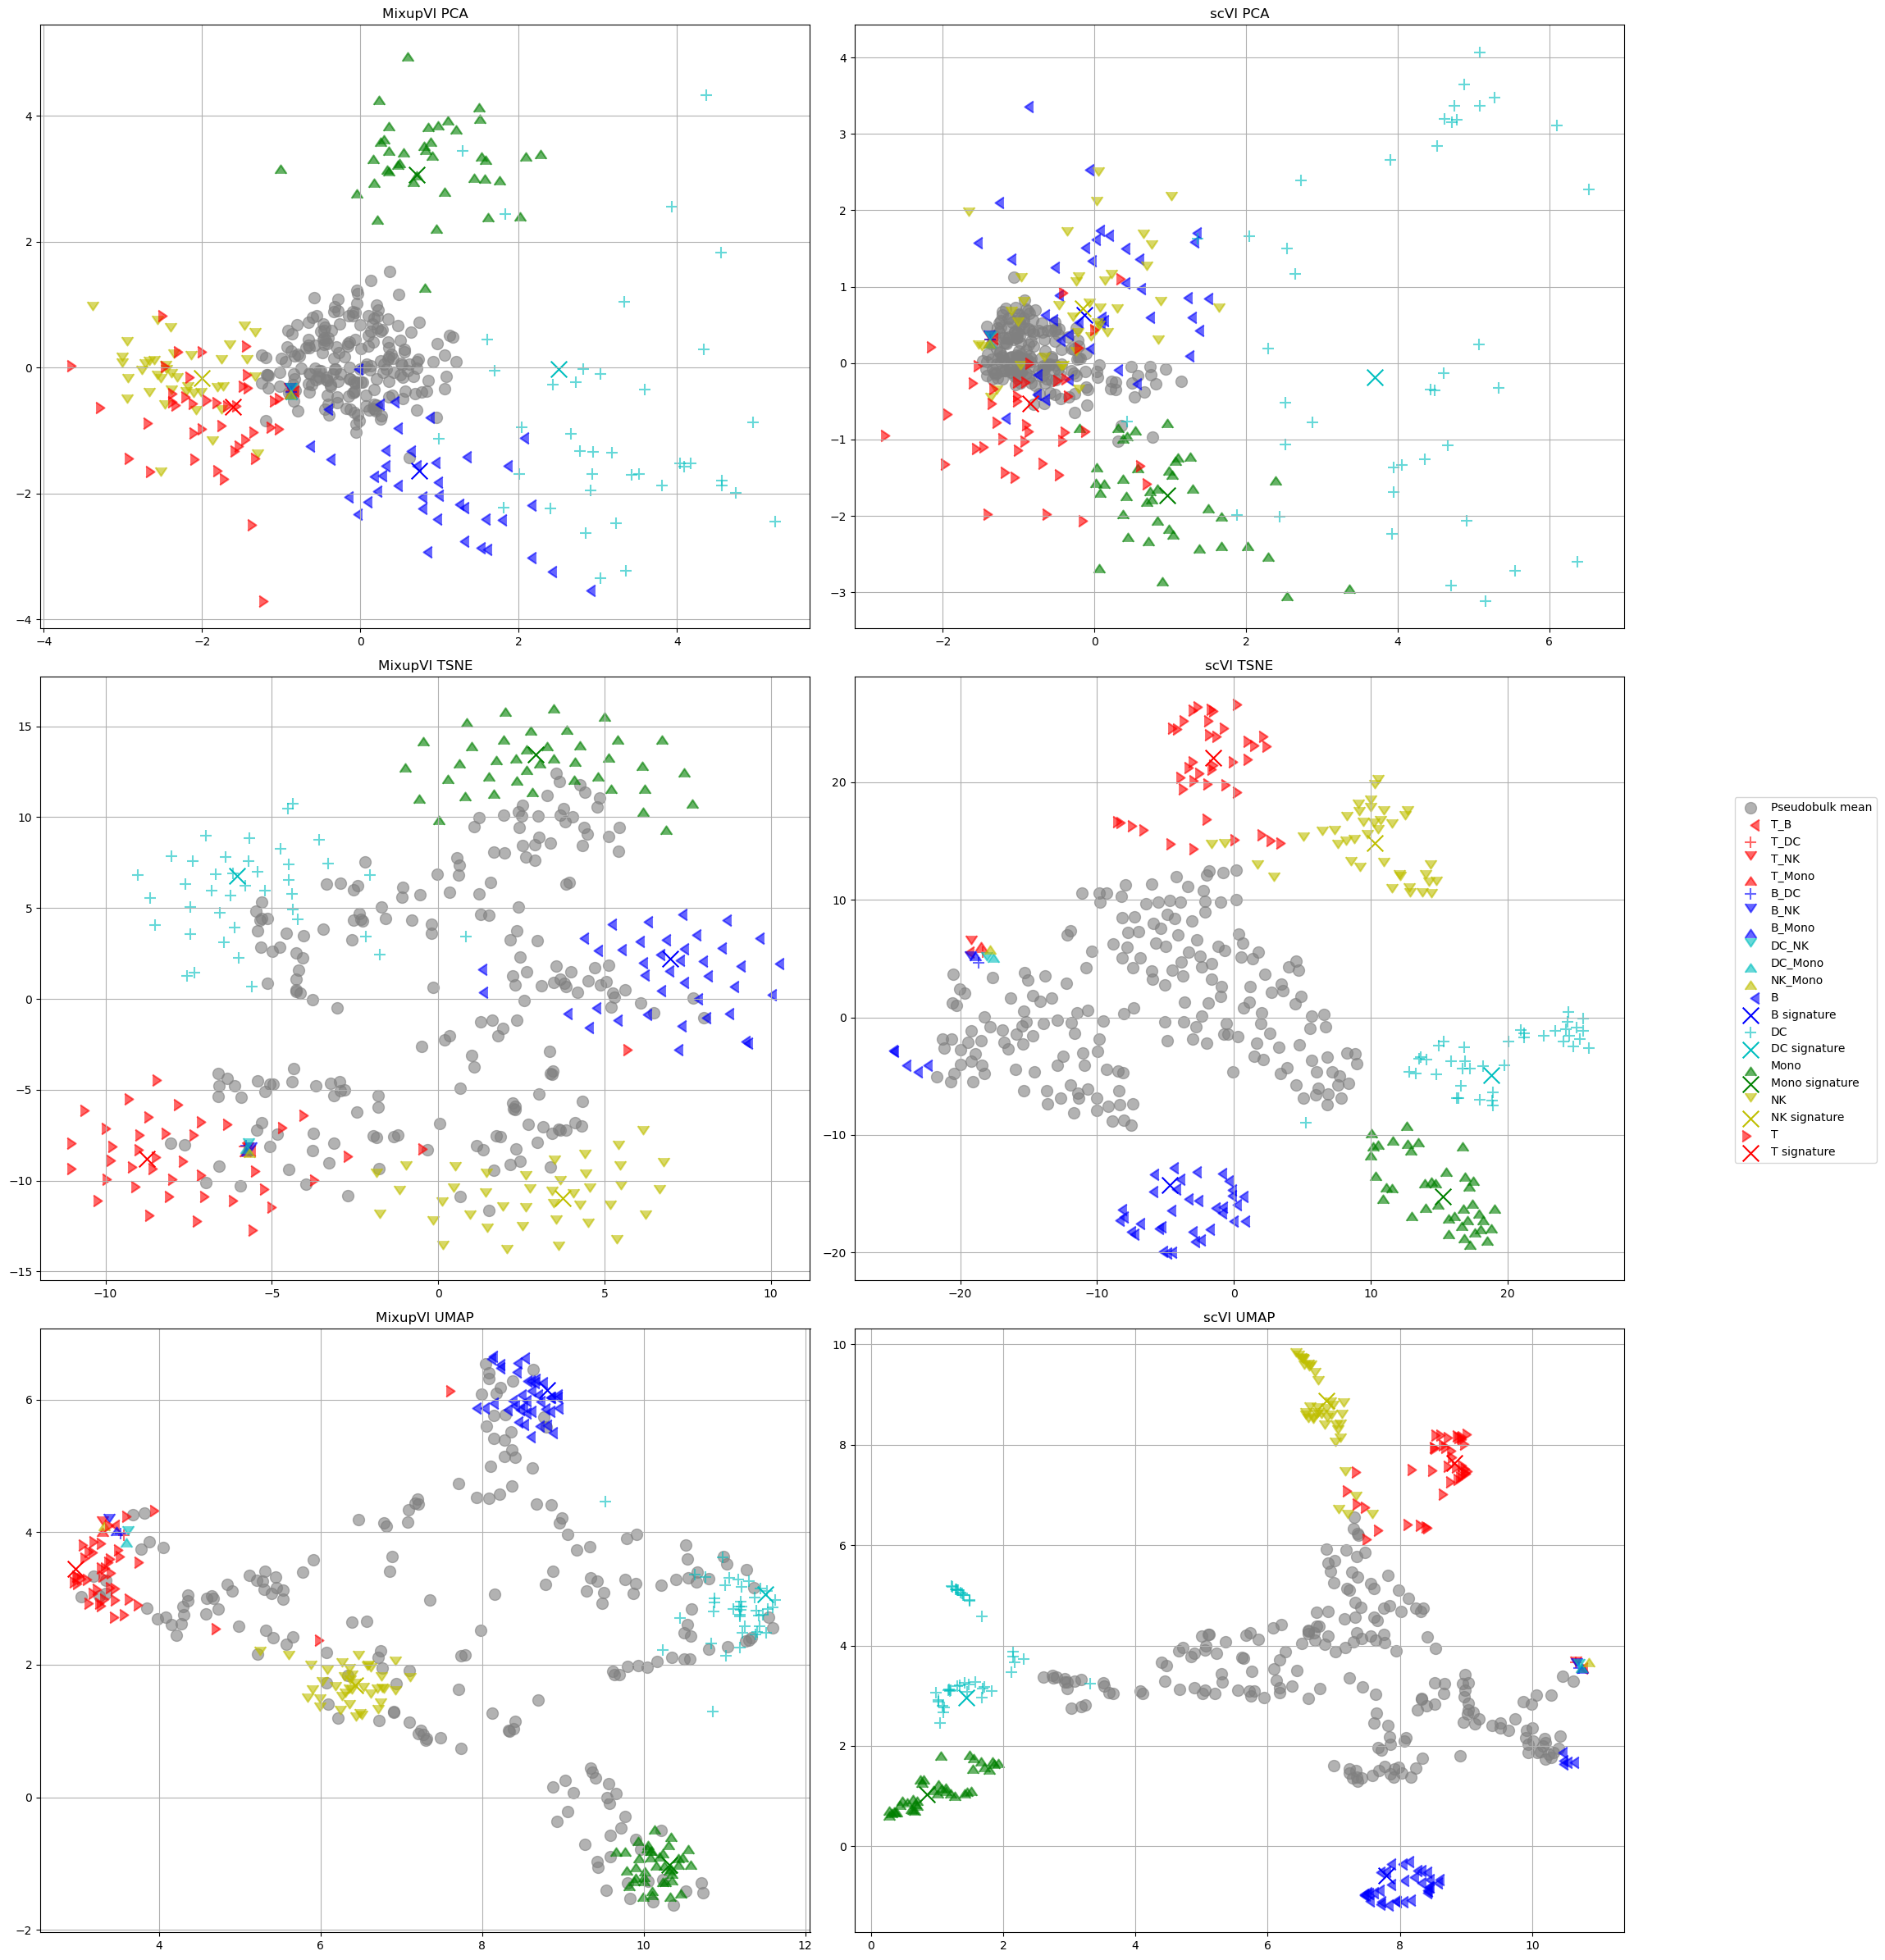

In [80]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt

# Concatenate latent representations for MixupVI
all_latent_mixup = np.concatenate([
    latent_sc_mixup,
    latent_pseudobulk_mean_mixup,
    latent_signature_mean_mixup,
    *[latent_pseudobulks_50_50_mixup[f"{pair[0]}_{pair[1]}"] for pair in pairs]
])

# Concatenate latent representations for scVI
all_latent_scvi = np.concatenate([
    latent_sc_scvi, 
    latent_pseudobulk_mean_scvi,
    latent_signature_mean_scvi,
    *[latent_pseudobulks_50_50_scvi[f"{pair[0]}_{pair[1]}"] for pair in pairs]
])

# Create labels array
labels = np.concatenate([
    sc_cell_type,
    np.array(['Pseudobulk mean']*len(latent_pseudobulk_mean_mixup)),
    latent_signature_cell_type_mean_mixup,
    *[np.array([f"{pair[0]}_{pair[1]}"]) for pair in pairs]
])

# Initialize dimensionality reduction methods
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

# Perform dimensionality reduction for both models
latent_2d_pca_mixup = pca.fit_transform(all_latent_mixup)
latent_2d_tsne_mixup = tsne.fit_transform(all_latent_mixup)
latent_2d_umap_mixup = umap.fit_transform(all_latent_mixup)

latent_2d_pca_scvi = pca.fit_transform(all_latent_scvi)
latent_2d_tsne_scvi = tsne.fit_transform(all_latent_scvi)
latent_2d_umap_scvi = umap.fit_transform(all_latent_scvi)

# Create figure with six subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
titles = ['MixupVI', 'scVI']
methods = ['PCA', 'TSNE', 'UMAP']

sc_colors = {
    "B": np.array([0.0, 0.0, 1.0]),
    "T": np.array([1.0, 0.0, 0.0]),
    "Mono": np.array([0.0, 1.0, 0.0]),
    "NK": np.array([0.0, 1.0, 1.0]),
    "DC": np.array([1.0, 1.0, 0.0]),
}

sc_marker = {
    "B": 4,
    "T": 5,
    "Mono": 6,
    "NK": 7,
    "DC": "+",
}

# Helper function to plot on a given axis
def plot_latent_space(latent_2d, ax, title):
    # Get indices for different data types
    n_sc = len(latent_sc_mixup)
    n_pseudo = len(latent_pseudobulk_mean_mixup)
    n_signature = len(latent_signature_mean_mixup)
    
    # Plot pseudobulk points
    pseudo_idx = slice(n_sc, n_sc + n_pseudo)
    ax.scatter(latent_2d[pseudo_idx, 0], latent_2d[pseudo_idx, 1],
              color='grey', s=100, label='Pseudobulk mean', alpha=0.6)
    
    unique_cell_types = np.unique(sc_cell_type)
    # Plot pseudobulk 50/50 points
    for i, pair in enumerate(pairs):    
        # Plot caretup and caretdown markers for the 50/50 mix
        pseudo_idx = n_sc + n_pseudo + n_signature + i
        ax.scatter(latent_2d[pseudo_idx, 0], latent_2d[pseudo_idx, 1],
                  color=sc_colors[pair[0]], marker=sc_marker[pair[1]], s=100, label=f'{pair[0]}_{pair[1]}', alpha=0.6)

    # Plot single cell points and signatures colored by cell type
    for i, cell_type in enumerate(unique_cell_types):
        # Plot single cells
        cell_mask = sc_cell_type == cell_type
        ax.scatter(latent_2d[:n_sc][cell_mask, 0], latent_2d[:n_sc][cell_mask, 1],
                  label=cell_type, alpha=0.6, s=100, color=sc_colors[cell_type], marker=sc_marker[cell_type])
        
        # Plot signatures
        sig_mask = latent_signature_cell_type_mean_mixup == cell_type
        sig_idx = np.where(sig_mask)[0] + n_sc + n_pseudo
        ax.scatter(latent_2d[sig_idx, 0], latent_2d[sig_idx, 1],
                  label=f"{cell_type} signature", marker="x", s=200, color=sc_colors[cell_type])
    
    ax.set_title(title)
    ax.grid(True)

# Plot all visualizations
latent_2d_dict = {
    (0, 0): (latent_2d_pca_mixup, 'MixupVI PCA'),
    (0, 1): (latent_2d_pca_scvi, 'scVI PCA'),
    (1, 0): (latent_2d_tsne_mixup, 'MixupVI TSNE'),
    (1, 1): (latent_2d_tsne_scvi, 'scVI TSNE'),
    (2, 0): (latent_2d_umap_mixup, 'MixupVI UMAP'),
    (2, 1): (latent_2d_umap_scvi, 'scVI UMAP')
}

for (i, j), (latent_2d, title) in latent_2d_dict.items():
    plot_latent_space(latent_2d, axes[i, j], title)

# Add legend to the right of the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()


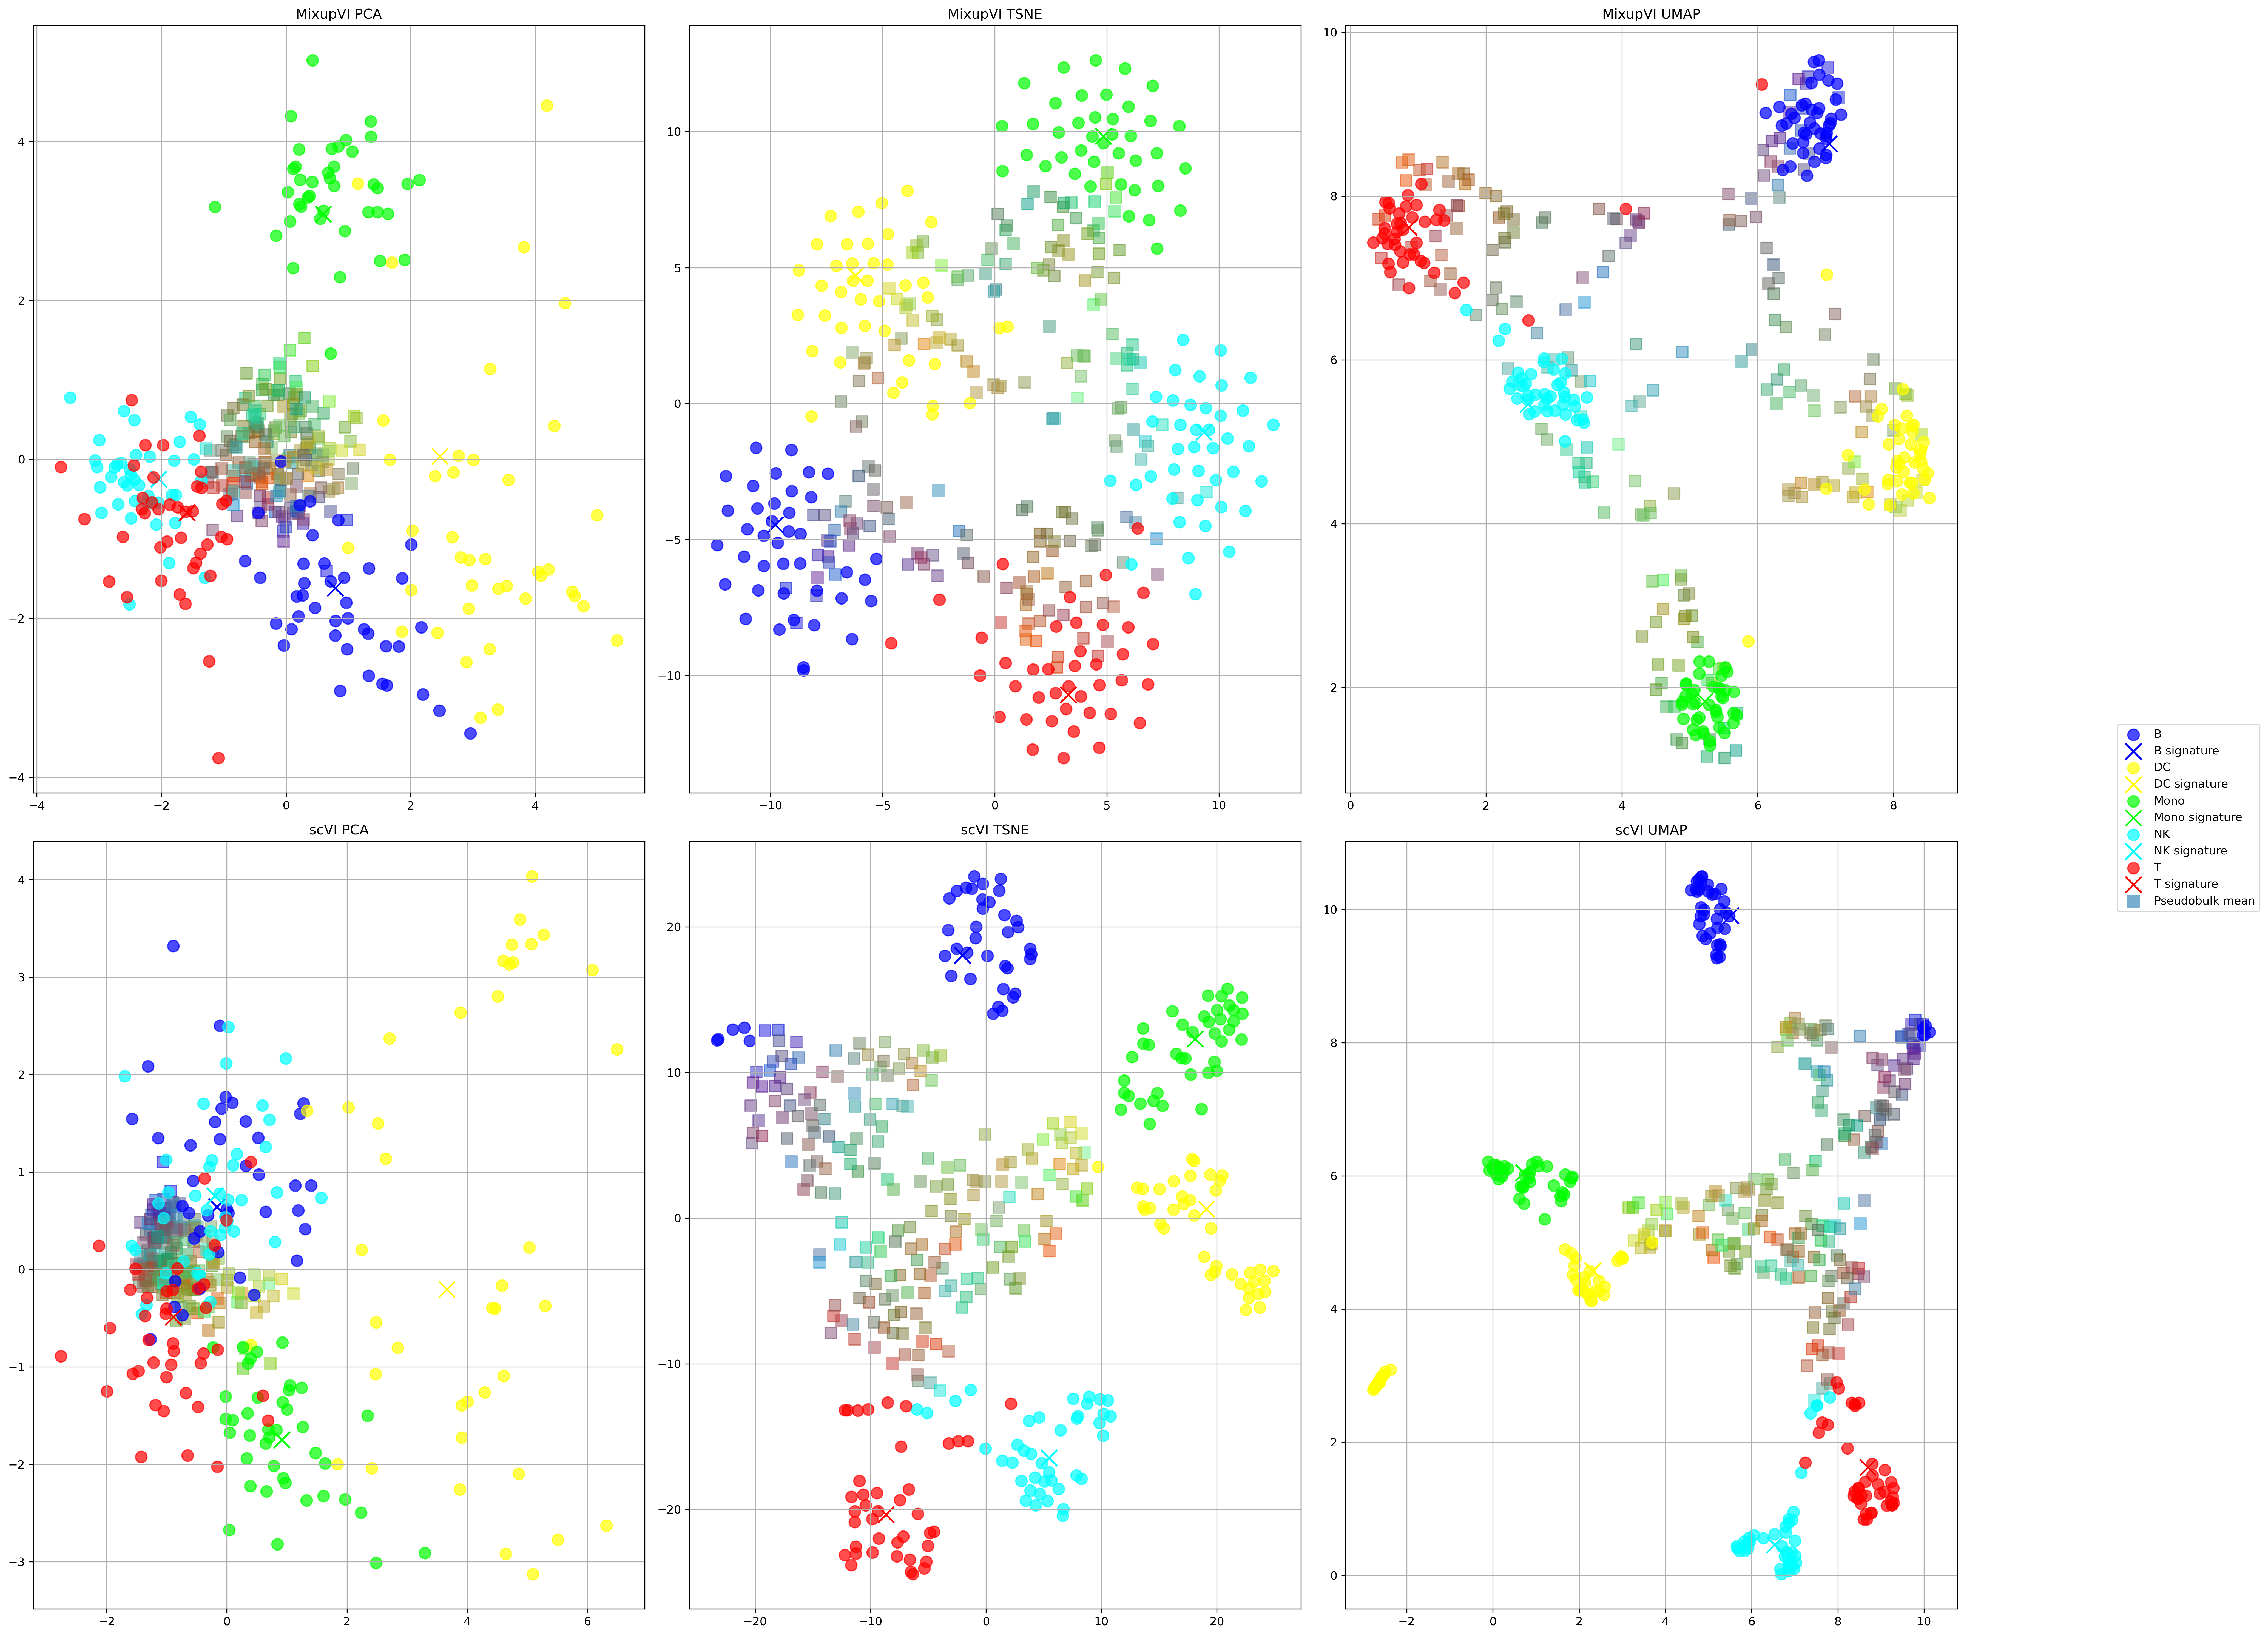

In [111]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt

# Concatenate latent representations for MixupVI
all_latent_mixup = np.concatenate([
    latent_sc_mixup,
    latent_signature_mean_mixup,
    latent_pseudobulk_mean_mixup,
])

# Concatenate latent representations for scVI
all_latent_scvi = np.concatenate([
    latent_sc_scvi, 
    latent_signature_mean_scvi,
    latent_pseudobulk_mean_scvi,
])

# Create labels array
labels = np.concatenate([
    sc_cell_type,
    np.array(['Pseudobulk mean']*len(latent_pseudobulk_mean_mixup)),
    latent_signature_cell_type_mean_mixup,
    *[np.array([f"{pair[0]}_{pair[1]}"]) for pair in pairs]
])

# Initialize dimensionality reduction methods
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

# Perform dimensionality reduction for both models
latent_2d_pca_mixup = pca.fit_transform(all_latent_mixup)
latent_2d_tsne_mixup = tsne.fit_transform(all_latent_mixup)
latent_2d_umap_mixup = umap.fit_transform(all_latent_mixup)

latent_2d_pca_scvi = pca.fit_transform(all_latent_scvi)
latent_2d_tsne_scvi = tsne.fit_transform(all_latent_scvi)
latent_2d_umap_scvi = umap.fit_transform(all_latent_scvi)

# Create figure with six subplots - now 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 20), dpi=300)
titles = ['MixupVI', 'scVI']
methods = ['PCA', 'TSNE', 'UMAP']

sc_colors = {
    "B": np.array([0.0, 0.0, 1.0]),
    "T": np.array([1.0, 0.0, 0.0]),
    "Mono": np.array([0.0, 1.0, 0.0]),
    "NK": np.array([0.0, 1.0, 1.0]),
    "DC": np.array([1.0, 1.0, 0.0]),
}

# Helper function to plot on a given axis
def plot_latent_space(latent_2d, ax, title):
    # Get indices for different data types
    n_sc = len(latent_sc_mixup)
    n_signature = len(latent_signature_mean_mixup)
    
    # Plot pseudobulk points
    for i, row in enumerate(pseudobulks_data_mean["df_proportions_test"].iterrows()):
        pseudo_idx = n_sc + n_signature + i
        ax.scatter(latent_2d[pseudo_idx, 0], latent_2d[pseudo_idx, 1],
                  color= row[1]["T"] * sc_colors["T"] + row[1]["B"] * sc_colors["B"] + row[1]["Mono"] * sc_colors["Mono"] + row[1]["NK"] * sc_colors["NK"] + row[1]["DC"] * sc_colors["DC"], s=100, marker="s", alpha=0.5)
    
    unique_cell_types = np.unique(sc_cell_type)
    # Plot single cell points and signatures colored by cell type
    for i, cell_type in enumerate(unique_cell_types):
        # Plot single cells
        cell_mask = sc_cell_type == cell_type
        ax.scatter(latent_2d[:n_sc][cell_mask, 0], latent_2d[:n_sc][cell_mask, 1],
                  label=cell_type, alpha=0.7, s=100, color=sc_colors[cell_type])
        
        # Plot signatures
        sig_mask = latent_signature_cell_type_mean_mixup == cell_type
        sig_idx = n_sc + np.where(sig_mask)[0]
        ax.scatter(latent_2d[sig_idx, 0], latent_2d[sig_idx, 1],
                  label=f"{cell_type} signature", marker="x", s=200, color=sc_colors[cell_type])
        
    ax.scatter(None, None, label="Pseudobulk mean", s=100, marker="s", alpha=0.6)
    ax.set_title(title)
    ax.grid(True)

# Plot all visualizations
latent_2d_dict = {
    (0, 0): (latent_2d_pca_mixup, 'MixupVI PCA'),
    (1, 0): (latent_2d_pca_scvi, 'scVI PCA'),
    (0, 1): (latent_2d_tsne_mixup, 'MixupVI TSNE'),
    (1, 1): (latent_2d_tsne_scvi, 'scVI TSNE'),
    (0, 2): (latent_2d_umap_mixup, 'MixupVI UMAP'),
    (1, 2): (latent_2d_umap_scvi, 'scVI UMAP')
}

for (i, j), (latent_2d, title) in latent_2d_dict.items():
    plot_latent_space(latent_2d, axes[i, j], title)

# Add legend to the right of the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()
